# Bonus 03 - Coverage gallery: three promises that look green until you slice them

> "Can we put the guarantee on one slide?" - legal, five minutes before the launch review

This notebook is a small visual gallery. The scenario, data, plots, and language are ours:
Hearthstone has two kinds of neighborhoods, quiet streets and volatile riverfront blocks.
Three interval systems walk into the review. One has marginal coverage but poor slice
behavior, one adapts locally, and one is simply under-covered.

What you will learn:

- Why marginal coverage is a dashboard headline, not the whole dashboard.
- How the same 90% overall number can hide different experiences by slice.
- Why adaptive width is a product behavior, not just a prettier plot.


In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260707
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED"
)
alpha = 0.10


## 1. A market built to expose the trap

The mean price curve is learnable. The noise is the trap. Quiet streets have small price
surprises; riverfront homes have the same average curve but much larger surprises. A
constant-width interval can look great overall while quietly spending the error budget in
the slice with the largest dollar risk.

This is an idealized teaching gallery, not a deployment recipe. The first band is
calibrated in-sample around the simulator's true mean, and the adaptive band uses the
simulator's true noise curve as an oracle. Real notebooks earn those quantities with held-
out calibration data and fitted models; here we expose the geometry without extra plumbing.


In [2]:
rng = np.random.default_rng(RANDOM_SEED)
n = 5000
size = rng.uniform(60, 260, size=n)
riverfront = rng.binomial(1, 0.22, size=n).astype(bool)
mu = 180 + 2.2 * size + 30 * np.sin(size / 28)
sigma = np.where(riverfront, 95 + 0.22 * size, 35 + 0.06 * size)
y = mu + rng.normal(0, sigma)

target = 1 - alpha
z = stats.norm.ppf(1 - alpha / 2)
# System A: idealized marginal calibration around the true simulator mean.
q_level = math.ceil((n + 1) * target) / n
q_global = np.quantile(np.abs(y - mu), q_level, method="higher")
lo_global, hi_global = mu - q_global, mu + q_global

# System B: oracle local adaptivity from the simulator's true noise curve.
lo_local, hi_local = mu - z * sigma, mu + z * sigma

# System C: the impressive-looking but wrong band.
lo_narrow, hi_narrow = mu - 0.55 * q_global, mu + 0.55 * q_global

systems = {
    "marginal constant": (lo_global, hi_global, BLUE),
    "local adaptive": (lo_local, hi_local, PURPLE),
    "too narrow": (lo_narrow, hi_narrow, RED),
}

def coverage_report(name, lo, hi):
    hit = (y >= lo) & (y <= hi)
    rows = []
    for label, mask in [
        ("overall", np.ones_like(hit, dtype=bool)),
        ("quiet streets", ~riverfront),
        ("riverfront", riverfront),
    ]:
        n_slice = int(mask.sum())
        cov = float(hit[mask].mean())
        se = float(np.sqrt(target * alpha / n_slice))
        if cov < target - 2 * se:
            status = "below noise band"
        elif cov > target + 2 * se:
            status = "above noise band"
        else:
            status = "within noise band"
        rows.append({
            "system": name,
            "slice": label,
            "coverage": cov,
            "n": n_slice,
            "two_se": 2 * se,
            "status": status,
            "mean_width": float(np.mean((hi - lo)[mask])),
        })
    return pd.DataFrame(rows)

report = pd.concat([coverage_report(name, lo, hi) for name, (lo, hi, _) in systems.items()])
report.pivot(index="system", columns="slice", values=["coverage", "mean_width"]).round(3)


coverage                          mean_width                         
slice              overall quiet streets riverfront    overall quiet streets riverfront
system                                                                                 
local adaptive        0.90         0.901      0.896    210.962       146.875    427.958
marginal constant     0.90         0.985      0.612    222.851       222.851    222.851
too narrow            0.73         0.835      0.373    122.568       122.568    122.568

## 2. The gallery

Do not read the plots as model diagnostics; read them as a vocabulary lesson. The blue
system makes one promise to everyone. The purple system lets the interval breathe where the
market is loud. The red system is the classic overconfident dashboard: narrow, attractive,
and wrong.


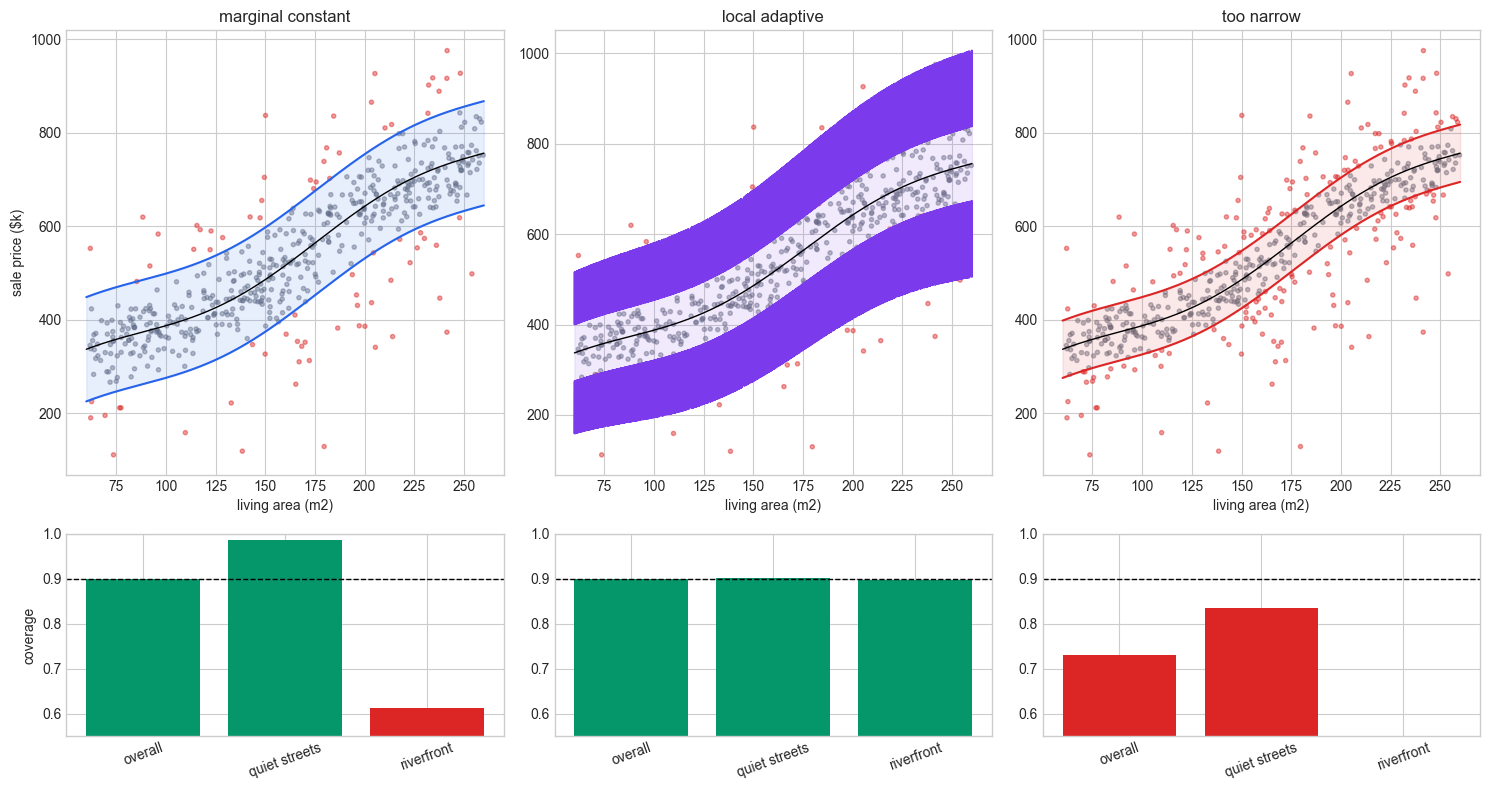

In [3]:
show_idx = np.r_[
    np.flatnonzero(~riverfront)[:350],
    np.flatnonzero(riverfront)[:180],
]
show_idx = show_idx[np.argsort(size[show_idx])]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={"height_ratios": [2.2, 1.0]})
for col, (name, (lo, hi, color)) in enumerate(systems.items()):
    ax = axes[0, col]
    hit = (y >= lo) & (y <= hi)
    ax.scatter(size[show_idx], y[show_idx], s=9, color=np.where(hit[show_idx], GRAY, RED), alpha=0.45)
    order = np.argsort(size)
    ax.plot(size[order], mu[order], color="black", linewidth=1.0, label="mean price curve")
    ax.plot(size[order], lo[order], color=color, linewidth=1.5)
    ax.plot(size[order], hi[order], color=color, linewidth=1.5)
    ax.fill_between(size[order], lo[order], hi[order], color=color, alpha=0.10)
    ax.set_title(name)
    ax.set_xlabel("living area (m2)")
    if col == 0:
        ax.set_ylabel("sale price ($k)")

    bar_ax = axes[1, col]
    rows = report[report["system"] == name].set_index("slice").loc[["overall", "quiet streets", "riverfront"]]
    colors = [RED if status == "below noise band" else GREEN for status in rows["status"]]
    bar_ax.bar(rows.index, rows["coverage"], color=colors)
    bar_ax.axhline(1 - alpha, color="black", linestyle="--", linewidth=1)
    bar_ax.set_ylim(0.55, 1.0)
    bar_ax.tick_params(axis="x", rotation=20)
    if col == 0:
        bar_ax.set_ylabel("coverage")
plt.tight_layout()


## 3. The slide legal actually needs

The launch slide should not say "coverage is 90%" and stop. It should say:

1. The marginal promise is the headline.
2. Slice coverage is the evidence that the headline is not hiding pain.
3. Width is the price paid for honesty.

That is field guide section 12 in one picture.


In [4]:
review = report.copy()
review["target"] = target
review[["system", "slice", "coverage", "target", "two_se", "status", "mean_width", "n"]].sort_values(
    ["system", "slice"]
).round(3)


,system,slice,coverage,target,two_se,status,mean_width,n
0,local adaptive,overall,0.900,0.9,0.008,within noise band,210.962,5000
1,local adaptive,quiet streets,0.901,0.9,0.010,within noise band,146.875,3860
2,local adaptive,riverfront,0.896,0.9,0.018,within noise band,427.958,1140
0,marginal constant,overall,0.900,0.9,0.008,within noise band,222.851,5000
1,marginal constant,quiet streets,0.985,0.9,0.010,above noise band,222.851,3860
2,marginal constant,riverfront,0.612,0.9,0.018,below noise band,222.851,1140
0,too narrow,overall,0.730,0.9,0.008,below noise band,122.568,5000
1,too narrow,quiet streets,0.835,0.9,0.010,below noise band,122.568,3860
2,too narrow,riverfront,0.373,0.9,0.018,below noise band,122.568,1140


The status column is deliberately not a naive green/red comparison to 0.900. A slice at
0.896 with roughly one thousand examples is not a failure; it is ordinary sampling noise.
Red is reserved for coverage outside a rough two-standard-error band, the same caution the
main course uses when discussing the calibration lottery.


## 4. Common mistakes to avoid

1. **Calling every value below 0.900 a failure.** Coverage is measured with noise. Look at
   sample size and a rough uncertainty band before escalating.
2. **Forgetting the oracle label on teaching plots.** The local adaptive band here uses
   the simulator's true noise curve. A real product must estimate that behavior and then
   calibrate it.
3. **Treating the gallery as an implementation.** This notebook is a picture of concepts;
   notebooks 02, 05, and 08 are the implementation templates.


### The one-line summary

A coverage gallery should make one idea impossible to unsee: marginal coverage is the
front door, but slice coverage and width are the rooms where the product actually lives.
